# Shot Creation Regression Analysis

In [1]:
from __future__ import annotations
import warnings
from pathlib import Path
import polars as pl
import psutil
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

warnings.filterwarnings("ignore")

DATA_DIR = Path.cwd().parent / "Additional"
STATSBOMB_DIR = DATA_DIR / "Statsbomb"

_process = psutil.Process()

def mem_report():
    return f"{_process.memory_info().rss / 1024**2:.1f} MB"

df = pl.read_parquet(DATA_DIR / "for_regression.parquet")
df = df.to_pandas()

In [2]:
# shape check
print(df.shape)

# null check
print(df.isnull().sum())

# binary variable creation; was a shot taken?
df['has_shot'] = (df['n_shots'] > 0).astype(int)
print(df['has_shot'].value_counts(normalize=True))

(104407, 22)
possession_type     0
OFF_BACKS           0
OFF_MIDFIELDERS     0
OFF_FORWARDS        0
OFF_GOALKEEPER      0
OFF_C0              0
OFF_C1              0
OFF_C2              0
OFF_C3              0
OFF_C4              0
DEF_BACKS           0
DEF_MIDFIELDERS     0
DEF_FORWARDS        0
DEF_GOALKEEPER      0
DEF_C0              0
DEF_C1              0
DEF_C2              0
DEF_C3              0
DEF_C4              0
total_xg            0
n_shots             0
duration_minutes    0
dtype: int64
has_shot
0    0.592987
1    0.407013
Name: proportion, dtype: float64


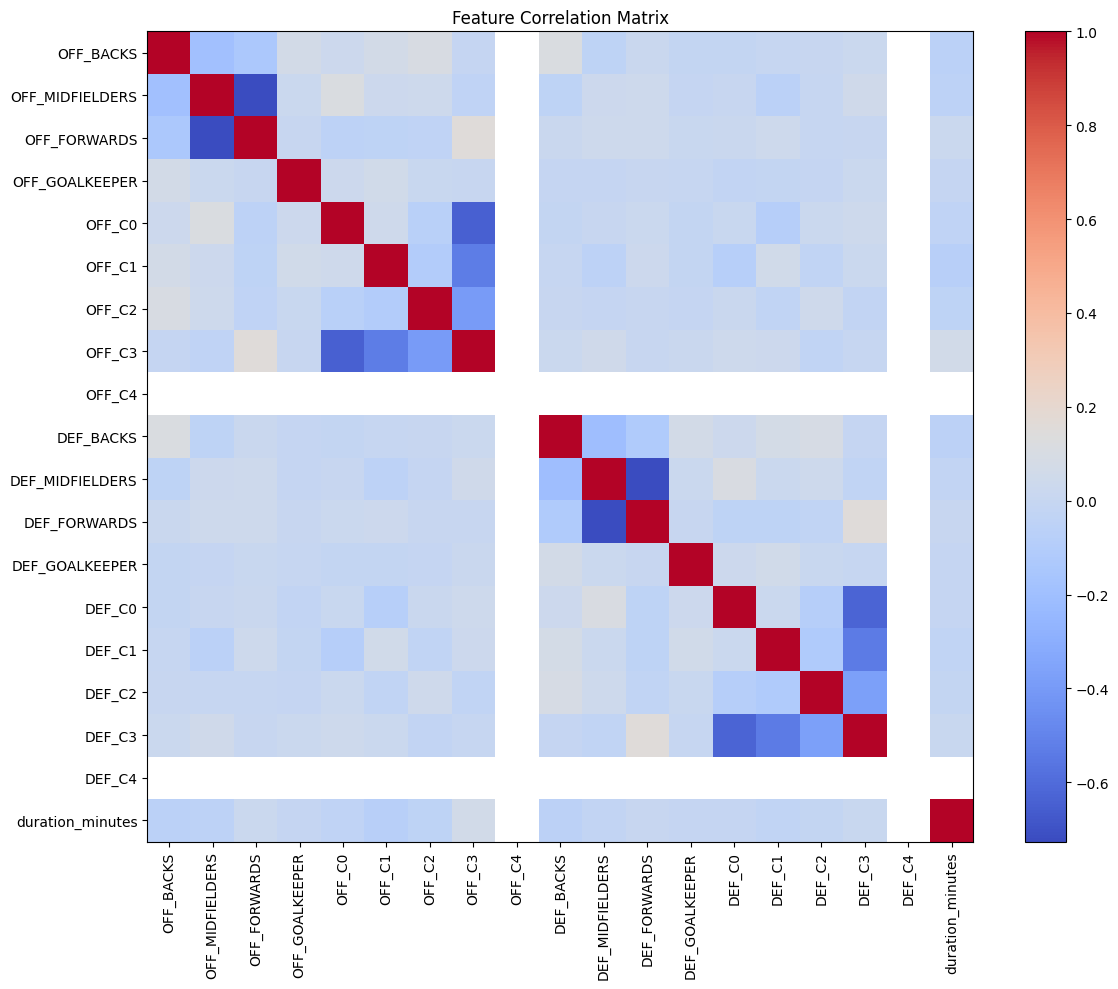

In [3]:
## correlation check

numeric_features = [col for col in df.columns if col != 'possession_type' and col != 'has_shot' and col != 'total_xg' and col != 'n_shots']

corr_matrix = df[numeric_features].corr()
plt.figure(figsize=(12, 10))
plt.imshow(corr_matrix, cmap='coolwarm', aspect='auto')
plt.colorbar()
plt.xticks(range(len(numeric_features)), numeric_features, rotation=90)
plt.yticks(range(len(numeric_features)), numeric_features)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

Potential issues:

* OFF_BACKS and OFF_MIDFIELDERS show strong neg. corr. with each other, which makes sense: if you have more backs you have fewer midfielders. Same pattern on the defensive side with DEF_BACKS and DEF_MIDFIELDERS. This is expected.
* OFF_C3 and OFF_C2 show a notable positive correlation, and similar patterns exist among some of the defensive cluster columns. Worth watching in the VIF results.

Good:

* Offensive and defensive features show very little correlation with each other (the off-diagonal quadrants are mostly light blue), which is good. That means they're capturing independent information.
* duration_minutes is largely uncorrelated with everything else, which is also good.

In [4]:
#create dummies
df_model = pd.get_dummies(df, columns=['possession_type'], drop_first=True)
feature_cols = [col for col in df_model.columns 
                if col not in ['has_shot', 'total_xg', 'n_shots']]

X_vif = df_model[feature_cols].astype(float)

vif_data = pd.DataFrame({
    'feature': feature_cols,
    'VIF': [variance_inflation_factor(X_vif.values, i) 
            for i in range(X_vif.shape[1])]
}).sort_values('VIF', ascending=False)

print(vif_data.to_string())

                                      feature           VIF
16                                     DEF_C3  38973.632795
7                                      OFF_C3  37063.141207
9                                   DEF_BACKS  24931.829462
0                                   OFF_BACKS  22690.646887
10                            DEF_MIDFIELDERS  18693.284208
1                             OFF_MIDFIELDERS  16912.302734
13                                     DEF_C0  13680.645293
4                                      OFF_C0  12196.244888
11                               DEF_FORWARDS   9011.998909
2                                OFF_FORWARDS   8328.427595
15                                     DEF_C2   6364.099293
6                                      OFF_C2   5711.314769
14                                     DEF_C1   5237.428110
5                                      OFF_C1   4381.448664
12                             DEF_GOALKEEPER   1701.684429
3                              OFF_GOALK

VIF values are extremely high (anything above 10 is bad). That means there's severe multicollinearity in the lineup count columns. 
A few things to highlight:
* The NaN values for OFF_C4 and DEF_C4 mean those columns are perfectly predicted by the other columns. They're the redundant ones in the lineup sum.
* The position counts (BACKS, MIDFIELDERS, FORWARDS, GOALKEEPER) are all massively inflated because they sum to 11. 
* The cluster columns (C0-C4) have the same problem; they likely sum to the number of outfield players. 
* The possession type dummies and duration_minutes are completely fine; VIFs all under 3.

### Reduced Feature Set

In [5]:
feature_cols = (
    ['duration_minutes',
     'OFF_MIDFIELDERS', 'OFF_FORWARDS', 'OFF_GOALKEEPER',
     'OFF_C0', 'OFF_C1', 'OFF_C2', 'OFF_C3',
     'DEF_MIDFIELDERS', 'DEF_FORWARDS', 'DEF_GOALKEEPER',
     'DEF_C0', 'DEF_C1', 'DEF_C2', 'DEF_C3']
    + [col for col in df_model.columns if col.startswith('possession_type_')]
)

X_vif = df_model[feature_cols].astype(float)

vif_data = pd.DataFrame({
    'feature': feature_cols,
    'VIF': [variance_inflation_factor(X_vif.values, i) 
            for i in range(X_vif.shape[1])]
}).sort_values('VIF', ascending=False)

print(vif_data.to_string())

                                      feature         VIF
3                              OFF_GOALKEEPER  235.798189
10                             DEF_GOALKEEPER  224.744756
7                                      OFF_C3  140.139293
14                                     DEF_C3  133.403523
1                             OFF_MIDFIELDERS   65.828077
8                             DEF_MIDFIELDERS   65.223294
11                                     DEF_C0   48.984569
4                                      OFF_C0   48.343983
2                                OFF_FORWARDS   33.614156
9                                DEF_FORWARDS   33.231966
13                                     DEF_C2   23.078182
6                                      OFF_C2   22.923258
12                                     DEF_C1   19.194200
5                                      OFF_C1   18.129082
21       possession_type_Middle Third - Short    2.890877
15    possession_type_Attacking Third - Short    2.826524
16   possessio

Still high in a lot of places. Dropping BACKS/C4 helped a little but main problem still there. The cluster columns and position counts are still summing to a constant.
The raw counts are inherently collinear by construction. Might need to convert them to proportions instead of counts, which breaks the sum-to-constant constraint.

### Even More Reduced Feature Set

In [6]:
feature_cols = (
    ['duration_minutes',
     'OFF_C0', 'OFF_C1', 'OFF_C2', 'OFF_C3',
     'DEF_C0', 'DEF_C1', 'DEF_C2', 'DEF_C3']
    + [col for col in df_model.columns if col.startswith('possession_type_')]
)

X_vif = df_model[feature_cols].astype(float)

vif_data = pd.DataFrame({
    'feature': feature_cols,
    'VIF': [variance_inflation_factor(X_vif.values, i) 
            for i in range(X_vif.shape[1])]
}).sort_values('VIF', ascending=False)

print(vif_data.to_string())

                                      feature        VIF
4                                      OFF_C3  54.915869
8                                      DEF_C3  52.944873
5                                      DEF_C0  20.673245
1                                      OFF_C0  20.179031
7                                      DEF_C2  10.775833
3                                      OFF_C2  10.646841
6                                      DEF_C1   8.665524
2                                      OFF_C1   8.237077
15       possession_type_Middle Third - Short   2.874038
9     possession_type_Attacking Third - Short   2.809606
10   possession_type_Defensive Third - Direct   2.766541
12    possession_type_Defensive Third - Short   2.698117
13      possession_type_Middle Third - Direct   2.397087
14     possession_type_Middle Third - Patient   1.915629
11  possession_type_Defensive Third - Patient   1.236255
0                            duration_minutes   1.202470


Still not ideal. Let's look at just the cluster columns

### Just Cluster Columns

In [7]:
feature_cols = (
    ['duration_minutes',
     'OFF_C0', 'OFF_C1', 'OFF_C2', 'OFF_C3',
     'DEF_C0', 'DEF_C1', 'DEF_C2', 'DEF_C3']
    + [col for col in df_model.columns if col.startswith('possession_type_')]
)

X_vif = df_model[feature_cols].astype(float)

vif_data = pd.DataFrame({
    'feature': feature_cols,
    'VIF': [variance_inflation_factor(X_vif.values, i) 
            for i in range(X_vif.shape[1])]
}).sort_values('VIF', ascending=False)

print(vif_data.to_string())

                                      feature        VIF
4                                      OFF_C3  54.915869
8                                      DEF_C3  52.944873
5                                      DEF_C0  20.673245
1                                      OFF_C0  20.179031
7                                      DEF_C2  10.775833
3                                      OFF_C2  10.646841
6                                      DEF_C1   8.665524
2                                      OFF_C1   8.237077
15       possession_type_Middle Third - Short   2.874038
9     possession_type_Attacking Third - Short   2.809606
10   possession_type_Defensive Third - Direct   2.766541
12    possession_type_Defensive Third - Short   2.698117
13      possession_type_Middle Third - Direct   2.397087
14     possession_type_Middle Third - Patient   1.915629
11  possession_type_Defensive Third - Patient   1.236255
0                            duration_minutes   1.202470


C3 is still the biggest problem at ~54, C0 is still high at ~20. C1 and C2 are borderline. The possession type dummies and duration are good.
Given that the clusters are global and C3/C0 appear on both offense and defense with very similar VIF values, most likely explanation is that C3 and C0 are simply very common archetypes that appear frequently on both teams simultaneously. In other words, OFF_C3 and DEF_C3 are nearly redundant.
Instead of having separate OFF and DEF columns for each cluster, computing the difference might be the move here. This should capture tactical mismatches between the two lineups rather than just raw counts.

In [8]:
for c in ['C0', 'C1', 'C2', 'C3']:
    df_model[f'DIFF_{c}'] = df_model[f'OFF_{c}'] - df_model[f'DEF_{c}']

feature_cols = (
    ['duration_minutes',
     'DIFF_C0', 'DIFF_C1', 'DIFF_C2', 'DIFF_C3']
    + [col for col in df_model.columns if col.startswith('possession_type_')]
)

X_vif = df_model[feature_cols].astype(float)

vif_data = pd.DataFrame({
    'feature': feature_cols,
    'VIF': [variance_inflation_factor(X_vif.values, i) 
            for i in range(X_vif.shape[1])]
}).sort_values('VIF', ascending=False)

print(vif_data.to_string())

                                      feature        VIF
4                                     DIFF_C3  15.117862
1                                     DIFF_C0   7.603788
2                                     DIFF_C1   5.353252
3                                     DIFF_C2   4.493638
0                            duration_minutes   1.161070
6    possession_type_Defensive Third - Direct   1.072763
10     possession_type_Middle Third - Patient   1.038361
9       possession_type_Middle Third - Direct   1.020077
11       possession_type_Middle Third - Short   1.012941
7   possession_type_Defensive Third - Patient   1.010585
5     possession_type_Attacking Third - Short   1.009550
8     possession_type_Defensive Third - Short   1.002097


DIFF_C3 remaining high even after taking the difference could indicate that C3 is correlated with the other cluster differences. Could be because the cluster sizes aren't independent of each other (if one team has more C3 players, they necessarily have fewer of the others).
We'll drop DIFF_C3 and see if that cleans everything up

In [9]:
feature_cols = (
    ['duration_minutes',
     'DIFF_C0', 'DIFF_C1', 'DIFF_C2']
    + [col for col in df_model.columns if col.startswith('possession_type_')]
)

X_vif = df_model[feature_cols].astype(float)

vif_data = pd.DataFrame({
    'feature': feature_cols,
    'VIF': [variance_inflation_factor(X_vif.values, i) 
            for i in range(X_vif.shape[1])]
}).sort_values('VIF', ascending=False)

print(vif_data.to_string())

                                      feature       VIF
0                            duration_minutes  1.160975
5    possession_type_Defensive Third - Direct  1.072737
9      possession_type_Middle Third - Patient  1.038235
2                                     DIFF_C1  1.028318
1                                     DIFF_C0  1.025807
8       possession_type_Middle Third - Direct  1.020071
3                                     DIFF_C2  1.017350
10       possession_type_Middle Third - Short  1.012936
6   possession_type_Defensive Third - Patient  1.010557
4     possession_type_Attacking Third - Short  1.009550
7     possession_type_Defensive Third - Short  1.002097


### Train/Test Split and Scaling

In [10]:
X = df_model[feature_cols].astype(float)
y = df_model['has_shot']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train size: {X_train.shape}")
print(f"Test size: {X_test.shape}")
print(f"Train shot rate: {y_train.mean():.4f}")
print(f"Test shot rate: {y_test.mean():.4f}")

Train size: (83525, 11)
Test size: (20882, 11)
Train shot rate: 0.4070
Test shot rate: 0.4070


### Model Fit and Initial Results

              precision    recall  f1-score   support

           0       0.67      0.91      0.77     12383
           1       0.73      0.36      0.48      8499

    accuracy                           0.69     20882
   macro avg       0.70      0.64      0.63     20882
weighted avg       0.70      0.69      0.66     20882

ROC-AUC: 0.7378


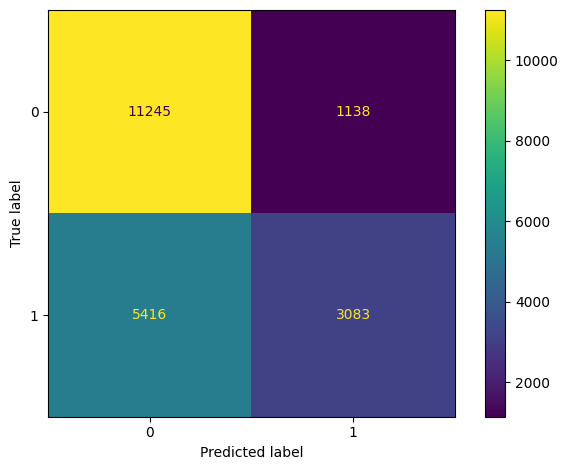

In [11]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.tight_layout()
plt.show()

ROC-AUC of 0.737 is not bad for event-level sports data. Model (correctly) ranks a random shot-producing possession above a non-shot possession 74% of the time. 

The asymmetry in the classification report is interesting. The model is much better at identifying non-shot possessions (recall of 0.91) than shot-producing ones (recall of 0.36). So it's a bit conservative: it predicts "no shot" more often than it probably should. You can also see this in the confusion matrix where 5,416 actual shot possessions are being called "no-shot". Not necessarily a problem, just means the model is better at ruling out shot creation rather than predicting it, which might actually a reasonable outcome given how complex soccer is!

### Inference

In [12]:
X_train_sm = sm.add_constant(X_train_scaled)
logit_model = sm.Logit(y_train, X_train_sm)
result = logit_model.fit()
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.623449
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:               has_shot   No. Observations:                83525
Model:                          Logit   Df Residuals:                    83513
Method:                           MLE   Df Model:                           11
Date:                Thu, 09 Apr 2026   Pseudo R-squ.:                 0.07740
Time:                        14:50:44   Log-Likelihood:                -52074.
converged:                       True   LL-Null:                       -56442.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.3045      0.008    -38.871      0.000      -0.320      -0.289
x1             1.2649      0.

In [13]:
feature_names = ['const'] + feature_cols

summary_df = pd.DataFrame({
    'variable': feature_names,
    'coefficient': result.params.values,
    'odds_ratio': np.exp(result.params.values),
    'p_value': result.pvalues.values
}).query("variable != 'const'").sort_values('odds_ratio', ascending=False)

print(summary_df.to_string())

                                     variable  coefficient  odds_ratio        p_value
1                            duration_minutes     1.264877    3.542657   0.000000e+00
5     possession_type_Attacking Third - Short     0.253370    1.288360  9.148180e-113
9       possession_type_Middle Third - Direct     0.157417    1.170483   5.230000e-50
6    possession_type_Defensive Third - Direct     0.065822    1.068036   4.930637e-09
8     possession_type_Defensive Third - Short     0.048233    1.049415   1.985637e-05
2                                     DIFF_C0    -0.049901    0.951324   2.830814e-11
4                                     DIFF_C2    -0.075537    0.927245   4.508002e-24
7   possession_type_Defensive Third - Patient    -0.075636    0.927154   5.926614e-17
11       possession_type_Middle Third - Short    -0.097021    0.907537   7.300092e-17
10     possession_type_Middle Third - Patient    -0.128629    0.879300   1.919763e-36
3                                     DIFF_C1    -0.15

### Cross-Validation

In [14]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X_train_scaled, y_train, 
                            cv=cv, scoring='roc_auc')
print(f"CV ROC-AUC scores: {cv_scores}")
print(f"Mean: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

CV ROC-AUC scores: [0.73792294 0.73683812 0.73092973 0.72979539 0.73065897]
Mean: 0.7332 (+/- 0.0034)


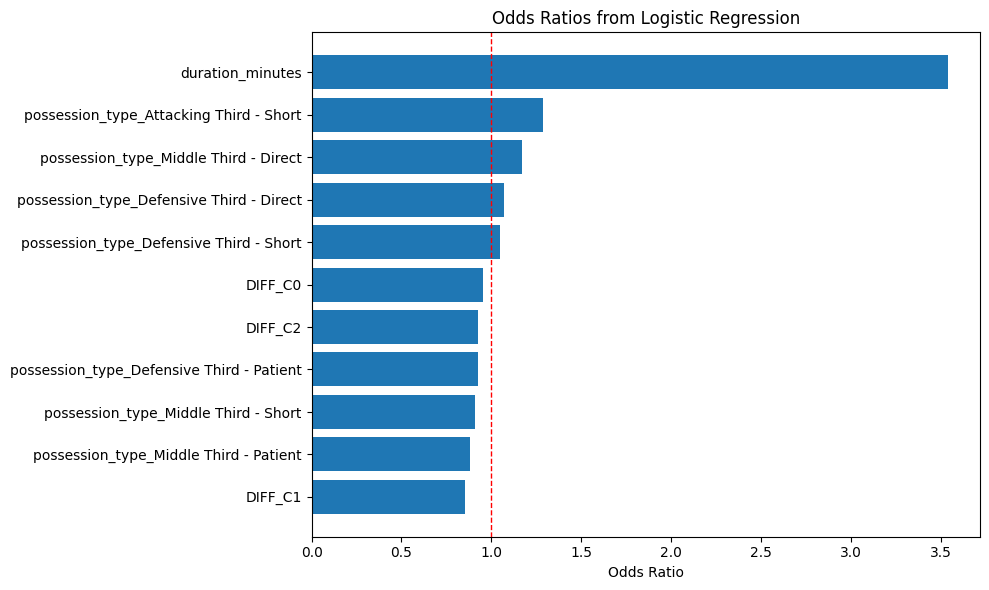

In [15]:
plot_df = summary_df.copy()
plot_df = plot_df.sort_values('odds_ratio')

plt.figure(figsize=(10, 6))
plt.barh(plot_df['variable'], plot_df['odds_ratio'])
plt.axvline(x=1, color='red', linestyle='--', linewidth=1)
plt.xlabel('Odds Ratio')
plt.title('Odds Ratios from Logistic Regression')
plt.tight_layout()
plt.show()

#### Graph Interpretation:

Above the red line = increases shot probability:

* duration_minutes overwhelming effect: longer possessions are by far the strongest predictor of shot creation
* "Attacking Third - Short" and "Middle Third - Direct" are the most shot-productive possession types relative to the "Attacking Third - Patient" baseline
* "Defensive Third - Direct" and "Defensive Third - Short" are just barely above 1, so marginally positive

Below the red line = decreases shot probability:

* DIFF_C1 is the strongest negative cluster effect, which means that when the offensive team has more C1 players relative to the defense, shots are actually *less* likely
* "Middle Third - Patient" and "Middle Third - Short" are the weakest possession types for shot creation
* DIFF_C0 and DIFF_C2 are both negative but are close to 1, so only modest effects

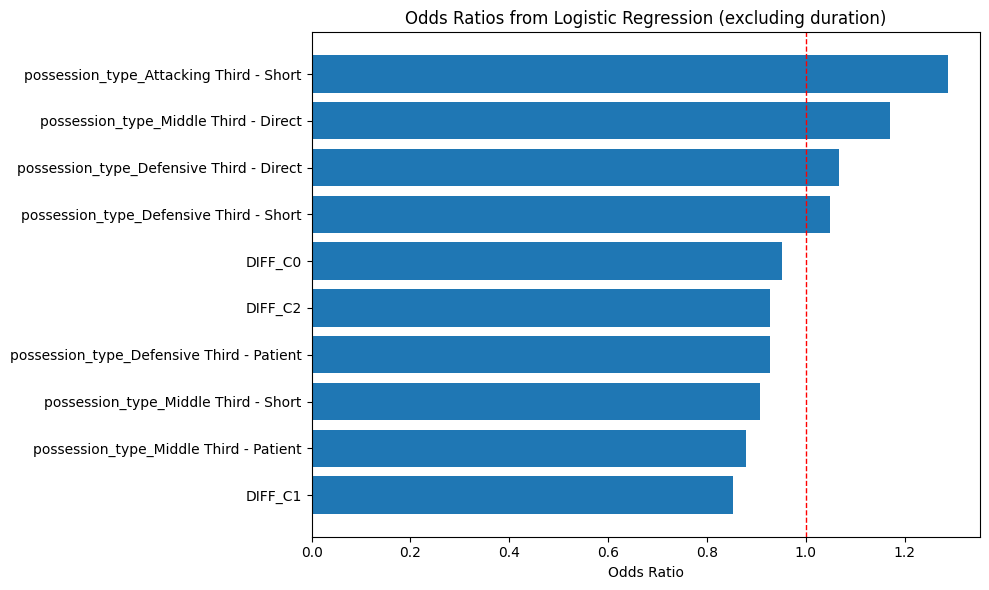

In [16]:
plot_df_no_duration = plot_df[plot_df['variable'] != 'duration_minutes']

plt.figure(figsize=(10, 6))
plt.barh(plot_df_no_duration['variable'], plot_df_no_duration['odds_ratio'])
plt.axvline(x=1, color='red', linestyle='--', linewidth=1)
plt.xlabel('Odds Ratio')
plt.title('Odds Ratios from Logistic Regression (excluding duration)')
plt.tight_layout()
plt.show()

#### Summary:
Logistic regression model predicting whether a possession produces a shot, with proper VIF checks, train/test split with stratification, scaling, cross-validation, and inference via statsmodels.

#### Key findings:

* Duration is the dominant predictor: longer possessions are dramatically more likely to produce shots
* "Attacking Third - Short" and "Middle Third - Direct" are the strongest possession types for shot creation once lineup composition is controlled for
* DIFF_C1 is the most notable cluster finding: offensive teams with more C1 players relative to the defense are less likely to produce shots, suggesting C1 may represent a more defensive archetype
* The model is stable and generalizes well; CV AUC of 0.733 w/ very low variance, nearly identical to test AUC of 0.738

#### To note:

* Reference category is "Attacking Third - Patient"
* DIFF columns represent offensive minus defensive player counts for each archetype, with C3 as implicit reference
* The 104k row dataset is a subset of the full 664k possessions due to the lineup join
* Men's and women's matches are pooled, which is a limitation worth acknowledging given the clusters were defined separately